# LangGraph 개요 (Overview)

**LangGraph**는 LLM 기반 에이전트와 복잡한 워크플로우를 구축하기 위한 프레임워크입니다.
그래프 구조를 통해 상태 관리, 분기, 루프, 병렬 처리를 자연스럽게 표현할 수 있습니다.

이 노트북은 LangGraph의 핵심 개념을 개괄적으로 다루며,
각 주제의 심화 학습은 해당 교재 파일을 참조하세요.

**참고**: [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

# LangSmith 추적 (선택적 - API 키가 있을 때만 활성화)
langsmith_api_key = os.getenv("LANGCHAIN_API_KEY", "")
if langsmith_api_key:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"

In [2]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-mini", model_provider="openai")

## 1. LangGraph란 무엇인가 

LangGraph는 LangChain 생태계의 일부로, **상태를 가진 그래프(Stateful Graph)** 를
사용하여 AI 에이전트와 워크플로우를 구축합니다.

### 왜 그래프인가?

- **순차 체인(Chain)**: 미리 정해진 A → B → C 순서로만 실행 → 유연성 부족
- **그래프(Graph)**: 조건에 따라 분기하고 루프 가능 → 복잡한 워크플로우 자연스럽게 표현
- 에이전트 루프, 병렬 처리, HITL(사람 개입) 모두 그래프로 표현 가능

### 핵심 특징

| 특징 | 설명 |
|------|------|
| **상태 관리** | TypedDict 기반 공유 상태로 노드 간 데이터 전달 |
| **조건부 분기** | 런타임에 다음 실행 경로를 동적으로 결정 |
| **루프 지원** | 에이전트의 반복적 추론(Reasoning Loop) 구현 |
| **체크포인팅** | 실행 중간 상태 저장 및 복원 (Time Travel) |
| **사람 개입** | Human-in-the-Loop 패턴 내장 지원 |

## 2. 핵심 3요소: State, Node, Edge 

LangGraph의 모든 그래프는 **State**, **Node**, **Edge** 3가지 요소로 구성됩니다.

| 요소 | 정의 | 구현 방법 |
|------|------|-----------|
| **State (상태)** | 그래프 전체에서 공유되는 데이터 구조 | `TypedDict`로 정의 |
| **Node (노드)** | 상태를 읽고 수정하는 처리 단위 | Python 함수로 구현 |
| **Edge (엣지)** | 노드 간 연결 및 실행 순서 결정 | 정적/조건부 엣지로 연결 |

### 2.1 State — 공유 데이터 구조

State는 그래프의 모든 노드가 공유하는 데이터 구조입니다.
`TypedDict`를 사용하여 타입 안전하게 정의합니다.

- 각 노드는 State를 읽고, 변경된 키만 반환하면 자동으로 병합됩니다
- `Annotated` 타입과 `operator.add` 등을 사용하면 리스트 누적(append) 등 커스텀 병합 가능

In [3]:
from typing import TypedDict

# 기본 State 정의
class SimpleState(TypedDict):
    input: str    # 사용자 입력
    output: str   # 처리 결과

# 메시지 누적 State 예시
from typing import Annotated
import operator

class ChatState(TypedDict):
    messages: Annotated[list, operator.add]  # 메시지가 누적됨
    user_name: str

### 2.2 Node — 작업의 단위

Node는 State를 받아 처리한 뒤, **변경된 키만 딕셔너리로 반환**하는 Python 함수입니다.

- 함수 이름이 노드 이름이 됨 (또는 `add_node()`에서 지정)
- 비동기(`async def`)도 지원
- LLM 호출, API 호출, 데이터 처리 등 어떤 로직이든 가능

In [4]:
def process_node(state: SimpleState) -> dict:
    """입력을 처리하는 노드 — 변경된 키만 반환"""
    result = f"처리 완료: {state['input'].upper()}"
    return {"output": result}

def greeting_node(state: ChatState) -> dict:
    """인사 노드 — messages 리스트에 누적"""
    return {"messages": [f"안녕하세요, {state['user_name']}님!"]}

### 2.3 Edge — 흐름 제어

Edge는 노드 간의 연결을 정의합니다. 두 가지 유형이 있습니다:

| 유형 | 설명 | 사용 시점 |
|------|------|----------|
| **정적 엣지** | A → B 고정 연결 | 항상 같은 순서로 실행 |
| **조건부 엣지** | 런타임에 다음 노드 결정 | 분기/라우팅 필요 시 |

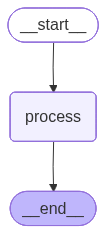

In [7]:
from langgraph.graph import StateGraph, START, END

# 정적 엣지 예시
builder = StateGraph(SimpleState)
builder.add_node("process", process_node)
builder.add_edge(START, "process")    # 시작 → process (항상)
builder.add_edge("process", END)      # process → 종료 (항상)
graph = builder.compile()
graph

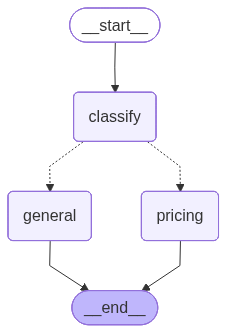

In [8]:
# 조건부 엣지 예시
class RouterState(TypedDict):
    query: str
    category: str
    result: str

def classify_node(state: RouterState) -> dict:
    """쿼리를 분류하는 노드"""
    if "가격" in state["query"] or "비용" in state["query"]:
        return {"category": "pricing"}
    return {"category": "general"}

def pricing_node(state: RouterState) -> dict:
    return {"result": "가격 관련 답변입니다."}

def general_node(state: RouterState) -> dict:
    return {"result": "일반 답변입니다."}

def route_by_category(state: RouterState) -> str:
    """조건부 라우팅 함수 — 다음 노드 이름을 반환"""
    return state["category"]

router_builder = StateGraph(RouterState)
router_builder.add_node("classify", classify_node)
router_builder.add_node("pricing", pricing_node)
router_builder.add_node("general", general_node)
router_builder.add_edge(START, "classify")
router_builder.add_conditional_edges(
    "classify",
    route_by_category,
    {"pricing": "pricing", "general": "general"}
)
router_builder.add_edge("pricing", END)
router_builder.add_edge("general", END)

router_graph = router_builder.compile()
router_graph

In [9]:
# 실행 테스트
print("=== 조건부 엣지 예시 ===")
res1 = router_graph.invoke({"query": "가격이 얼마인가요?", "category": "", "result": ""})
print(f"쿼리: '{res1['query']}' → 분류: {res1['category']} → 결과: {res1['result']}")

res2 = router_graph.invoke({"query": "사용법을 알려주세요", "category": "", "result": ""})
print(f"쿼리: '{res2['query']}' → 분류: {res2['category']} → 결과: {res2['result']}")

=== 조건부 엣지 예시 ===
쿼리: '가격이 얼마인가요?' → 분류: pricing → 결과: 가격 관련 답변입니다.
쿼리: '사용법을 알려주세요' → 분류: general → 결과: 일반 답변입니다.


## 3. StateGraph 구축 5단계 패턴 
모든 LangGraph 그래프는 동일한 5단계 패턴으로 구축됩니다:

| 단계 | 코드 | 설명 |
|------|------|------|
| ① State 정의 | `class MyState(TypedDict)` | 공유 데이터 구조 설계 |
| ② Node 작성 | `def my_node(state) -> dict` | 처리 함수 구현 |
| ③ Graph 생성 | `StateGraph(MyState)` | 빈 그래프 객체 생성 |
| ④ Edge 연결 | `add_node()`, `add_edge()` | 노드 등록 + 흐름 정의 |
| ⑤ Compile | `.compile()` | 실행 가능한 Runnable로 변환 |

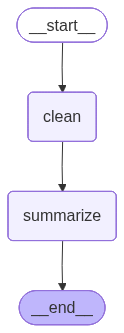

In [10]:
# 5단계 패턴 전체 예시

# ① State 정의
class PipelineState(TypedDict):
    text: str
    cleaned: str
    summary: str

# ② Node 작성
def clean_text(state: PipelineState) -> dict:
    """텍스트 정제 노드"""
    return {"cleaned": state["text"].strip().lower()}

def summarize_text(state: PipelineState) -> dict:
    """요약 노드"""
    return {"summary": f"요약: {state['cleaned'][:30]}..."}

# ③ Graph 생성
pipeline = StateGraph(PipelineState)

# ④ Edge 연결
pipeline.add_node("clean", clean_text)
pipeline.add_node("summarize", summarize_text)
pipeline.add_edge(START, "clean")
pipeline.add_edge("clean", "summarize")
pipeline.add_edge("summarize", END)

# ⑤ Compile
pipeline_graph = pipeline.compile()
pipeline_graph

In [17]:
# 실행
original_text = "   \t  안녕하세요!!!   LangGraph  는  정말  대단한   프레임워크  입니다... "
res = pipeline_graph.invoke({
    "text": original_text,
    "cleaned": "",
    "summary": ""
})
print(f"원본: {original_text}")
print()
print(f"정제: '{res['cleaned']}'")
print()
print(f"요약: '{res['summary']}'")

원본:    	  안녕하세요!!!   LangGraph  는  정말  대단한   프레임워크  입니다... 

정제: '안녕하세요!!!   langgraph  는  정말  대단한   프레임워크  입니다...'

요약: '요약: 안녕하세요!!!   langgraph  는  정말  대...'


## 4. Persistence와 Checkpointing 개요

**Checkpointer**는 그래프 실행 중간 상태를 저장하여 복원, 재실행, 디버깅을 가능하게 합니다.

| Checkpointer | 용도 | 특징 |
|--------------|------|------|
| `InMemorySaver` | 개발/테스트 전용 | 프로세스 종료 시 데이터 소멸 |
| `SqliteSaver` | 소규모, 단일 인스턴스 | 파일 기반, 추가 설치 불필요 |
| `PostgresSaver` | 프로덕션, 멀티 인스턴스 | 고가용성, 수평 확장 가능 |

### 핵심 개념

- **thread_id**: 대화 세션을 구분하는 고유 식별자 — 같은 ID면 이전 대화가 이어짐
- **checkpoint_id**: 각 실행 시점의 스냅샷 — 특정 시점으로 되돌리기 가능

**심화 학습**: [102_Memory_Concepts.py](102_Memory_Concepts.py) — 단기/장기 메모리, Store 기반 메모리

In [18]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def greet(name: str) -> str:
    """이름을 받아 인사합니다."""
    return f"안녕하세요, {name}님!"

# Checkpointer를 사용한 에이전트
agent = create_agent(model, tools=[greet], checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "demo_thread"}}

# 첫 번째 대화
result1 = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름은 홍길동이야."}]},
    config
)
print("응답 1:", result1["messages"][-1].content)

# 두 번째 대화 — 같은 thread_id이므로 이전 대화를 기억
result2 = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름이 뭐였지?"}]},
    config
)
print("응답 2:", result2["messages"][-1].content)

응답 1: 안녕하세요, 홍길동님! 무엇을 도와드릴까요?
응답 2: 당신의 이름은 홍길동입니다. 기억해 둘까요?


## 6. Human-in-the-Loop 개요 

**HITL(Human-in-the-Loop)** 은 에이전트 실행 중 사람의 승인이나 개입을 받는 패턴입니다.

### 주요 사용 사례

- 위험한 도구 호출 전 사람의 승인 요구
- 에이전트 판단의 중간 검토
- 에이전트에게 추가 정보 제공

### 구현 방법

LangGraph에서는 `HumanInTheLoopMiddleware`를 사용하여 구현합니다:

```python
from langchain.agents import create_agent, HumanInTheLoopMiddleware

hitl = HumanInTheLoopMiddleware(
    human_as_tool=True,
    tool_names=["dangerous_tool"]  # 승인이 필요한 도구 지정
)
agent = create_agent(model, tools=tools, middleware=[hitl])
```

**심화 학습**: [350_Middleware.py](350_Middleware.py) — 승인/수정/거부 플로우, 미들웨어 패턴

## 7. Time Travel 개요

**Time Travel**은 과거 특정 시점의 에이전트 상태로 돌아가 다시 실행하는 기능입니다.
Checkpointer가 있어야만 사용할 수 있습니다.

### 핵심 API 3종

| API | 역할 |
|-----|------|
| `agent.get_state_history(config)` | 해당 thread의 모든 과거 체크포인트 목록 조회 (최신 순) |
| `agent.update_state(config, values)` | 특정 체크포인트의 상태를 직접 수정 |
| `agent.invoke(msg, config with checkpoint_id)` | 특정 체크포인트 시점부터 재실행 |

### HITL 연계 패턴

1. 에이전트 실행 중 인터럽트 발생
2. 사람이 `get_state_history()`로 상태 이력 검토
3. `update_state()`로 문제 있는 상태 수정
4. 수정된 체크포인트부터 `invoke()`로 재실행

## 8. Workflow vs Agent — 설계 선택 가이드 
LangGraph로 구현할 수 있는 두 가지 패러다임을 명확히 구분해야 합니다:

| 구분 | 워크플로우 (Workflow) | 에이전트 (Agent) |
|------|----------------------|-----------------|
| **제어 흐름** | 개발자가 사전 정의 (결정론적) | LLM이 런타임에 결정 (자율적) |
| **예측 가능성** | 높음 — 항상 동일한 경로 | 낮음 — 상황에 따라 다양 |
| **유연성** | 낮음 | 높음 |
| **비용** | 낮음 (LLM 호출 횟수 예측 가능) | 높음 (LLM이 반복 호출 가능) |
| **적합한 작업** | 승인 플로우, ETL, 고정 파이프라인 | 개방형 리서치, 복잡한 추론 |

### 권장 사항: 가능하면 워크플로우를 사용하라

- 워크플로우는 예측 가능하고 디버깅이 쉬우며 비용이 통제됨
- 에이전트는 유연하지만 비용·지연 시간·불확실성이 높음
- **실무 조합 팁**: 워크플로우로 전체 흐름을 잡고, 복잡한 판단이 필요한 노드에만 LLM 에이전트 투입

## 주요 포인트 정리

1. **LangGraph**: 상태 기반 그래프로 에이전트와 워크플로우를 구축하는 프레임워크
2. **3요소**: State(TypedDict), Node(Python 함수), Edge(정적/조건부)
3. **5단계 패턴**: State 정의 → Node 작성 → Graph 생성 → Edge 연결 → Compile
4. **Pregel 모델**: 슈퍼스텝 기반 실행 — 활성 노드를 반복 처리하며 수렴
5. **Checkpointer**: 상태 저장/복원 — InMemorySaver(개발), SqliteSaver(소규모), PostgresSaver(프로덕션)
6. **HITL**: 에이전트 실행 중 사람의 승인/개입 패턴
7. **Time Travel**: 과거 체크포인트로 되돌아가 재실행
8. **Workflow vs Agent**: 예측 가능성이 중요하면 워크플로우, 유연성이 중요하면 에이전트

**관련 교재**:
- [102_Memory_Concepts.py](102_Memory_Concepts.py) — 단기/장기 메모리, Checkpointer, Store, Time Travel
- [350_Middleware.py](350_Middleware.py) — HITL 및 미들웨어 (승인/수정/거부, PII, 요약 등)
- [310_Subagents_Pattern.py](310_Subagents_Pattern.py) ~ [340_Skills_Pattern.py](340_Skills_Pattern.py) — 멀티 에이전트 패턴